
# Feature Selection

In this session you will learn the main families of **feature selection** methods and compare them on a synthetic classification problem with informative, redundant, repeated, and noisy variables.

## Learning goals
- Understand the difference between **filter**, **wrapper**, and **embedded** methods.
- See why different methods may select different features.
- Compare methods using both **ground-truth recovery** and **downstream model performance**.
- Build intuition with visualizations, not only with scores.


### FS Overview

You can categorize feature selection into three primary paradigms.

- __Filter Methods__: These methods evaluate the relevance of features using intrinsic properties of the data, completely independent of any machine learning algorithm.

    Mechanism: Uses statistical measures (e.g., Pearson correlation, ANOVA F-value, Chi-Square, Mutual Information) to assign a scoring to each feature. Features are ranked, and a threshold is applied.

    Pros & Cons: Extremely fast, highly scalable to high-dimensional data, and less prone to overfitting. However, they generally evaluate features in isolation and ignore feature interactions or the inductive bias of the downstream model.

- __Wrapper Methods__: These methods evaluate subsets of features by training and testing a specific machine learning model on them.

    Mechanism: Treats feature selection as a search problem (e.g., Forward Selection, Backward Elimination, Recursive Feature Elimination). It uses the model's performance (like accuracy or AUC) as the evaluation criterion.

    Pros & Cons: Can capture feature interactions and finds the best subset for that specific model. However, they are highly computationally expensive (often prohibitive for massive datasets) and carry a higher risk of overfitting to the training data.

- __Embedded Methods__: These methods perform feature selection dynamically as part of the model training process itself.

    Mechanism: The learning algorithm has built-in mechanisms to penalize or ignore irrelevant features. The classic examples are L1 regularization (Lasso), which drives weights of irrelevant features exactly to zero, and tree-based models (Random Forests, Gradient Boosting), which calculate feature importance based on split criteria.

    Pros & Cons: Strikes a balance. More computationally efficient than wrappers, captures feature interactions, and is tied to the model's objective function. The downside is that the selection is strictly tied to a specific model family.

### Key Literature References

Here you can find some references for this topic; note that this is a classical topic and there are many papers on it.

One of the main references are

1. Guyon, I., & Elisseeff, A. (2003). An introduction to variable and feature selection. Journal of Machine Learning Research (JMLR), 3, 1157-1182. https://jmlr.csail.mit.edu/papers/volume3/guyon03a/guyon03a.pdf

    
The Wrapper Method Foundation:

2. Kohavi, R., & John, G. H. (1997). Wrappers for feature subset selection. Artificial Intelligence, 97(1-2), 273-324. https://doi.org/10.1016/S0004-3702(97)00043-X

The Embedded/Lasso Benchmark:

3. Tibshirani, R. (1996). Regression shrinkage and selection via the lasso. Journal of the Royal Statistical Society: Series B (Methodological), 58(1), 267-288. https://doi.org/10.1111/j.2517-6161.1996.tb02080.x

A more modern review here:

4. Barbieri, M. C., Grisci, B. I., & Dorn, M. (2024). Analysis and comparison of feature selection methods towards performance and stability. Expert Systems with Applications, 245, 123667. https://doi.org/10.1016/j.eswa.2024.123667


You can find more information and many relevant references in the [wikipedia](https://en.wikipedia.org/wiki/Feature_selection) page on _feature selection_.



## Step 1 — Create a challenging classification dataset

We will generate a dataset with:
- **5 informative** features,
- **15 redundant** features,
- **5 repeated** features,
- 75 irrelevant noisy features.

Important detail: the truly informative variables are originally `Feature_0` to `Feature_4`, but then we **shuffle the columns** so the answer is hidden.


In [16]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import time

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE, SelectFromModel
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True


def generate_lab_data(n_samples=5000, random_state=40):
    """Generate a Madelon-style dataset and keep track of the true informative features."""
    X_raw, y = make_classification(
        n_samples=n_samples,
        n_features=100,
        n_informative=5,
        n_redundant=15,
        n_repeated=5,
        n_classes=2,
        n_clusters_per_class=16,
        flip_y=0.05,
        class_sep=0.8,
        shuffle=False,
        random_state=random_state,
    )

    feature_names = np.array([f"Feature_{i}" for i in range(100)])
    df_X = pd.DataFrame(X_raw, columns=feature_names)

    true_features = [f"Feature_{i}" for i in range(5)]

    np.random.seed(random_state)
    shuffled_columns = np.random.permutation(df_X.columns)
    df_X = df_X[shuffled_columns]

    return df_X, y, true_features


X, y, GROUND_TRUTH = generate_lab_data()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

print(f"Shape of X: {X.shape}")
print(f"Class balance: {np.bincount(y)}")
print(f"True informative features (hidden after shuffling): {GROUND_TRUTH}")


Shape of X: (5000, 100)
Class balance: [2496 2504]
True informative features (hidden after shuffling): ['Feature_0', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4']



## Step 2 — First visual intuition

Before applying feature selection, let us inspect:
- class balance,
- how an informative feature behaves,
- how a noisy feature behaves.

Even after shuffling, we still know the names of the 5 true informative features, so we can use them for explanation.


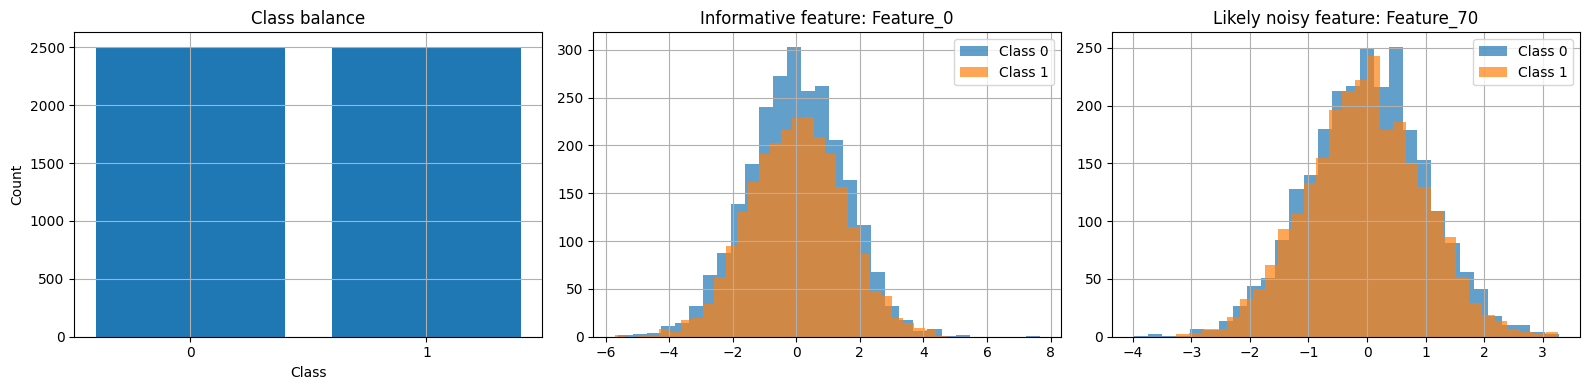

In [17]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1) class balance
class_counts = pd.Series(y).value_counts().sort_index()
axes[0].bar(class_counts.index.astype(str), class_counts.values)
axes[0].set_title('Class balance')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

# 2) informative feature
informative_feature = GROUND_TRUTH[0]
axes[1].hist(X.loc[y == 0, informative_feature], bins=30, alpha=0.7, label='Class 0')
axes[1].hist(X.loc[y == 1, informative_feature], bins=30, alpha=0.7, label='Class 1')
axes[1].set_title(f'Informative feature: {informative_feature}')
axes[1].legend()

# 3) likely noisy feature
candidate_noise = [c for c in X.columns if c not in GROUND_TRUTH][-1]
axes[2].hist(X.loc[y == 0, candidate_noise], bins=30, alpha=0.7, label='Class 0')
axes[2].hist(X.loc[y == 1, candidate_noise], bins=30, alpha=0.7, label='Class 1')
axes[2].set_title(f'Likely noisy feature: {candidate_noise}')
axes[2].legend()

plt.tight_layout()
plt.show()



## Step 3 — Baseline scoring helpers

We will score methods in two ways:

1. **Ground-truth recovery**: how many truly informative features were found.  
2. **Downstream usefulness**: how well a classifier performs when trained only on the selected subset.

This second metric is important because sometimes a method does **not** recover the exact ground-truth variables, but still keeps a very predictive subset because of redundancy.


In [18]:

def score_feature_selection(method_name, selected_features, execution_time, true_features):
    selected_set = set(selected_features)
    truth_set = set(true_features)
    found = selected_set.intersection(truth_set)

    print('-' * 55)
    print(f'{method_name.upper()}')
    print(f'Execution time      : {execution_time:.3f} s')
    print(f'Number selected     : {len(selected_features)}')
    print(f'True informative hit: {len(found)} / {len(truth_set)} ({len(found)/len(truth_set):.0%})')
    if found:
        print('Found informative   :', ', '.join(sorted(found)))
    print('-' * 55)


def evaluate_subset_with_logreg(selected_features, X_train, X_test, y_train, y_test):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000, random_state=42))
    ])
    pipe.fit(X_train[selected_features], y_train)
    pred = pipe.predict(X_test[selected_features])
    return {
        'accuracy': accuracy_score(y_test, pred),
        'f1': f1_score(y_test, pred)
    }


# small baseline: random selection
random.seed(1)
start_time = time.time()
random_features_selected = random.sample(list(X.columns), 10)
random_elapsed = time.time() - start_time

score_feature_selection('Random baseline (10 random features)', random_features_selected, random_elapsed, GROUND_TRUTH)
evaluate_subset_with_logreg(random_features_selected, X_train, X_test, y_train, y_test)


-------------------------------------------------------
RANDOM BASELINE (10 RANDOM FEATURES)
Execution time      : 0.000 s
Number selected     : 10
True informative hit: 0 / 5 (0%)
-------------------------------------------------------


{'accuracy': 0.6313333333333333, 'f1': 0.6383257030739045}


## Step 4 — Filter intuition: ANOVA vs Mutual Information

**Not all filter methods rank features in the same way**.

- **ANOVA F-score** prefers strong mean differences and mostly linear effects.
- **Mutual Information** can capture broader statistical dependence.

We will visualize the top-ranked features according to both scores.


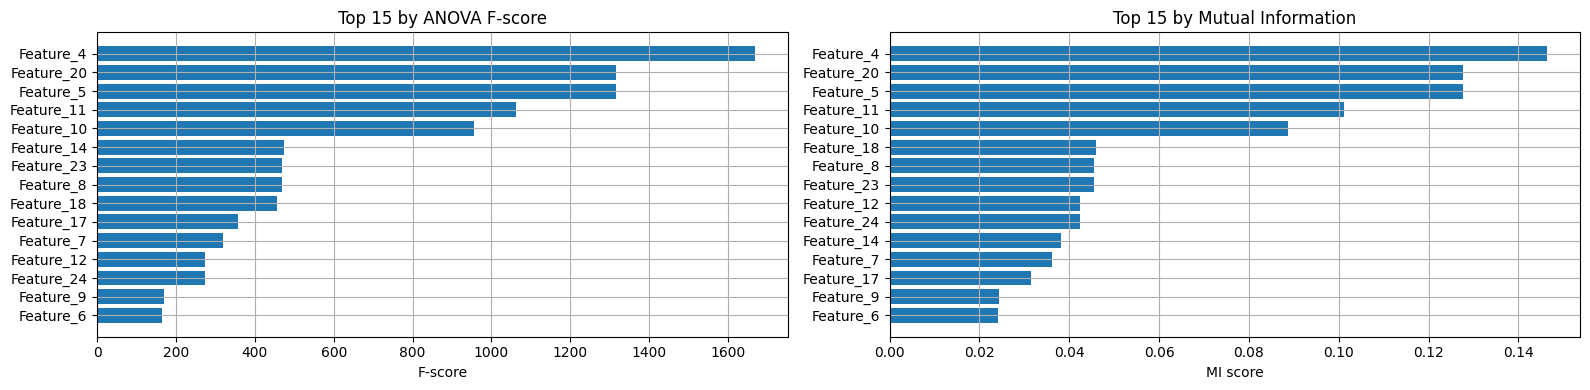

,feature,anova_f,mutual_info,is_true_informative
11,Feature_4,1667.224830,0.146398,True
30,Feature_20,1314.737733,0.127755,False
53,Feature_5,1314.737733,0.127755,False
5,Feature_11,1062.310929,0.101216,False
35,Feature_10,955.781404,0.088675,False
55,Feature_18,456.727073,0.045896,False
80,Feature_8,469.498458,0.045458,False
62,Feature_23,469.498458,0.045458,False
92,Feature_12,274.036501,0.042397,False
44,Feature_24,274.036501,0.042397,False


In [19]:

anova_scores, _ = f_classif(X, y)
mi_scores = mutual_info_classif(X, y, random_state=42)

score_df = pd.DataFrame({
    'feature': X.columns,
    'anova_f': anova_scores,
    'mutual_info': mi_scores,
    'is_true_informative': [f in GROUND_TRUTH for f in X.columns]
}).sort_values('anova_f', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

anova_top = score_df.sort_values('anova_f', ascending=False).head(15).iloc[::-1]
axes[0].barh(anova_top['feature'], anova_top['anova_f'])
axes[0].set_title('Top 15 by ANOVA F-score')
axes[0].set_xlabel('F-score')

mi_top = score_df.sort_values('mutual_info', ascending=False).head(15).iloc[::-1]
axes[1].barh(mi_top['feature'], mi_top['mutual_info'])
axes[1].set_title('Top 15 by Mutual Information')
axes[1].set_xlabel('MI score')

plt.tight_layout()
plt.show()

score_df.sort_values('mutual_info', ascending=False).head(10)



## Step 5 - Benchmark several feature-selection families

We now compare one example of each major family:
- a **filter** method,
- a **wrapper** method,
- and two **embedded** methods.

For each method we will measure:
- execution time,
- how many true informative variables are recovered,
- and later, how useful the selected subset is for downstream prediction.


In [20]:

def run_feature_selection_benchmark(X_train, y_train, k=10):
    results = []
    selections = {}

    methods = {}

    methods['Filter (ANOVA)'] = SelectKBest(score_func=f_classif, k=k)
    methods['Filter (Mutual Information)'] = SelectKBest(score_func=mutual_info_classif, k=k)
    methods['Wrapper (RFE + Decision Tree)'] = RFE(
        estimator=DecisionTreeClassifier(random_state=42),
        n_features_to_select=k,
        step=5,
    )

    # run simple sklearn selectors
    for method_name, selector in methods.items():
        start = time.time()
        selector.fit(X_train, y_train)
        elapsed = time.time() - start
        mask = selector.get_support()
        selected = X_train.columns[mask].tolist()
        selections[method_name] = selected
        results.append({
            'method': method_name,
            'execution_time_s': elapsed,
            'n_selected': len(selected),
            'n_true_found': len(set(selected) & set(GROUND_TRUTH)),
            'selected_features': selected,
        })

    # Embedded: random forest
    start = time.time()
    rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_selector = SelectFromModel(rf, prefit=True, max_features=k, threshold=-np.inf)
    rf_mask = rf_selector.get_support()
    rf_selected = X_train.columns[rf_mask].tolist()
    elapsed = time.time() - start
    selections['Embedded (Random Forest)'] = rf_selected
    results.append({
        'method': 'Embedded (Random Forest)',
        'execution_time_s': elapsed,
        'n_selected': len(rf_selected),
        'n_true_found': len(set(rf_selected) & set(GROUND_TRUTH)),
        'selected_features': rf_selected,
    })

    # Embedded: L1 logistic regression
    start = time.time()
    l1_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            penalty='l1', solver='liblinear', C=0.1,
            random_state=42, max_iter=2000
        ))
    ])

    l1_pipe.fit(X_train, y_train)
    coefs = np.abs(l1_pipe.named_steps['clf'].coef_[0])
    top_idx = np.argsort(coefs)[::-1][:k]
    l1_selected = X_train.columns[top_idx].tolist()
    elapsed = time.time() - start
    selections['Embedded (L1 Logistic)'] = l1_selected
    results.append({
        'method': 'Embedded (L1 Logistic)',
        'execution_time_s': elapsed,
        'n_selected': len(l1_selected),
        'n_true_found': len(set(l1_selected) & set(GROUND_TRUTH)),
        'selected_features': l1_selected,
    })

    return pd.DataFrame(results), selections


results_df, selections = run_feature_selection_benchmark(X_train, y_train, k=10)
results_df[['method', 'execution_time_s', 'n_selected', 'n_true_found']].sort_values('n_true_found', ascending=False)


,method,execution_time_s,n_selected,n_true_found
0,Filter (ANOVA),0.002001,10,1
1,Filter (Mutual Information),0.561079,10,1
2,Wrapper (RFE + Decision Tree),3.963087,10,1
3,Embedded (Random Forest),0.416464,10,1
4,Embedded (L1 Logistic),0.038418,10,1


In [21]:

for _, row in results_df.iterrows():
    score_feature_selection(row['method'], row['selected_features'], row['execution_time_s'], GROUND_TRUTH)


-------------------------------------------------------
FILTER (ANOVA)
Execution time      : 0.002 s
Number selected     : 10
True informative hit: 1 / 5 (20%)
Found informative   : Feature_4
-------------------------------------------------------
-------------------------------------------------------
FILTER (MUTUAL INFORMATION)
Execution time      : 0.561 s
Number selected     : 10
True informative hit: 1 / 5 (20%)
Found informative   : Feature_4
-------------------------------------------------------
-------------------------------------------------------
WRAPPER (RFE + DECISION TREE)
Execution time      : 3.963 s
Number selected     : 10
True informative hit: 1 / 5 (20%)
Found informative   : Feature_4
-------------------------------------------------------
-------------------------------------------------------
EMBEDDED (RANDOM FOREST)
Execution time      : 0.416 s
Number selected     : 10
True informative hit: 1 / 5 (20%)
Found informative   : Feature_4
--------------------------


## Step 6 — Compare methods visually

Show that methods differ in:
- **speed**,
- **number of true informative features recovered**,
- **downstream test performance**.


In [22]:

# evaluate predictive usefulness of each selected subset
perf_rows = []
for method_name, selected in selections.items():
    perf = evaluate_subset_with_logreg(selected, X_train, X_test, y_train, y_test)
    perf_rows.append({
        'method': method_name,
        'accuracy': perf['accuracy'],
        'f1': perf['f1']
    })

perf_df = pd.DataFrame(perf_rows)
summary_df = results_df.merge(perf_df, on='method')
summary_df = summary_df.sort_values('f1', ascending=False)
summary_df[['method', 'n_true_found', 'execution_time_s', 'accuracy', 'f1']]


,method,n_true_found,execution_time_s,accuracy,f1
0,Filter (ANOVA),1,0.002001,0.736000,0.733871
1,Filter (Mutual Information),1,0.561079,0.736000,0.733871
3,Embedded (Random Forest),1,0.416464,0.736000,0.733871
2,Wrapper (RFE + Decision Tree),1,3.963087,0.735333,0.733378
4,Embedded (L1 Logistic),1,0.038418,0.724000,0.724000


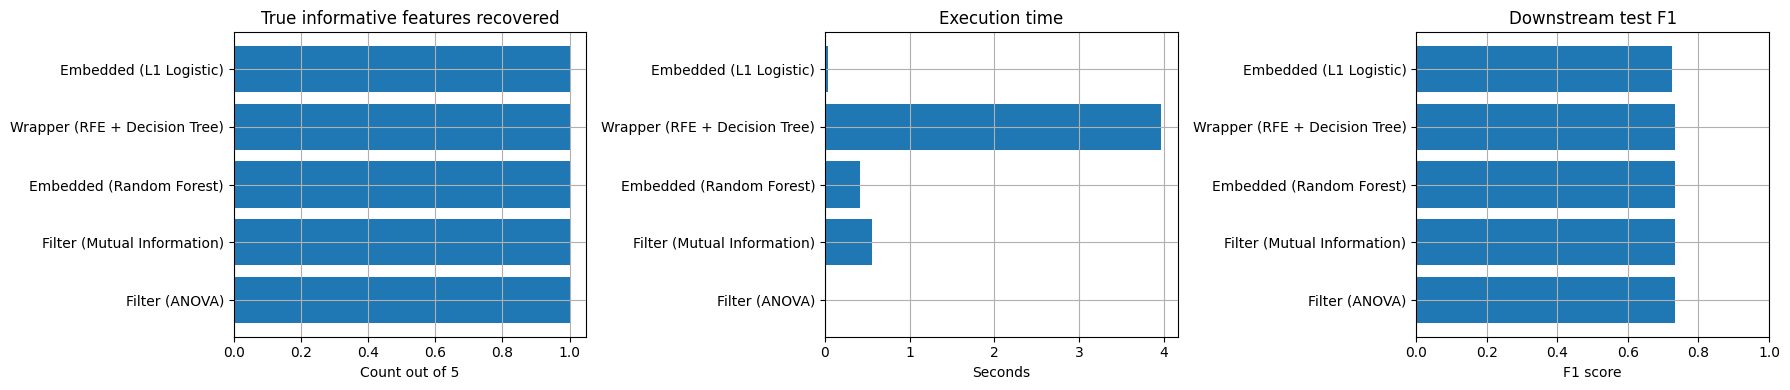

In [23]:

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
plot_df = summary_df.copy()

axes[0].barh(plot_df['method'], plot_df['n_true_found'])
axes[0].set_title('True informative features recovered')
axes[0].set_xlabel('Count out of 5')

axes[1].barh(plot_df['method'], plot_df['execution_time_s'])
axes[1].set_title('Execution time')
axes[1].set_xlabel('Seconds')

axes[2].barh(plot_df['method'], plot_df['f1'])
axes[2].set_title('Downstream test F1')
axes[2].set_xlabel('F1 score')
axes[2].set_xlim(0, 1)

plt.tight_layout()
plt.show()



## Step 7 — Overlap between methods

- Which features are selected by almost everyone?
- Which ones are method-specific?
- Does agreement between methods suggest stronger evidence?


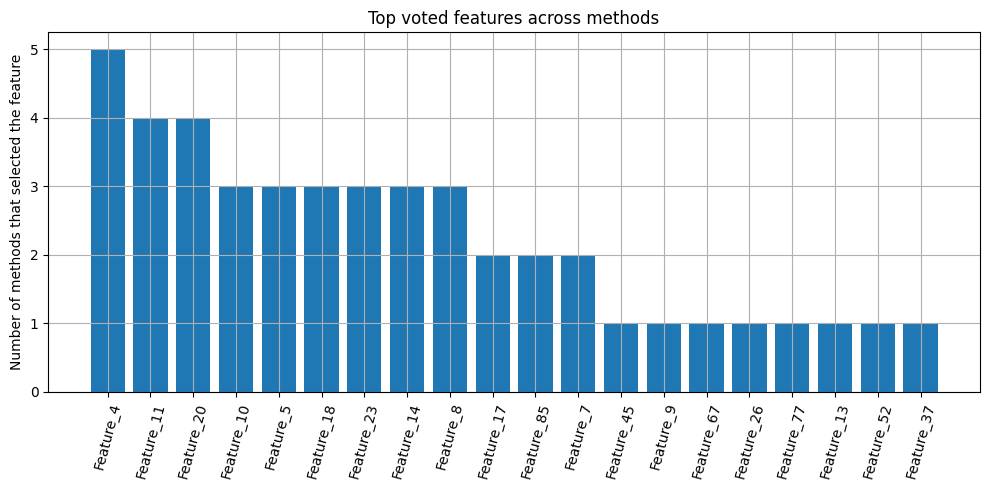

,feature,votes,is_true_informative
1,Feature_4,5,True
0,Feature_11,4,False
3,Feature_20,4,False
4,Feature_10,3,False
5,Feature_5,3,False
6,Feature_18,3,False
7,Feature_23,3,False
8,Feature_14,3,False
9,Feature_8,3,False
2,Feature_17,2,False


In [24]:

feature_vote_counter = {}
for method_name, selected in selections.items():
    for feat in selected:
        feature_vote_counter.setdefault(feat, 0)
        feature_vote_counter[feat] += 1

vote_df = pd.DataFrame({
    'feature': list(feature_vote_counter.keys()),
    'votes': list(feature_vote_counter.values()),
    'is_true_informative': [f in GROUND_TRUTH for f in feature_vote_counter.keys()]
}).sort_values(['votes', 'is_true_informative'], ascending=[False, False])

plt.figure(figsize=(10, 5))
plt.bar(vote_df['feature'].head(20), vote_df['votes'].head(20))
plt.xticks(rotation=75)
plt.ylabel('Number of methods that selected the feature')
plt.title('Top voted features across methods')
plt.tight_layout()
plt.show()

vote_df.head(20)



## Step 8 — How many features should we keep?

> “Why pick 10 features and not 5, 15, or 30?”

We will vary `k` for a simple filter method and observe how test performance changes.


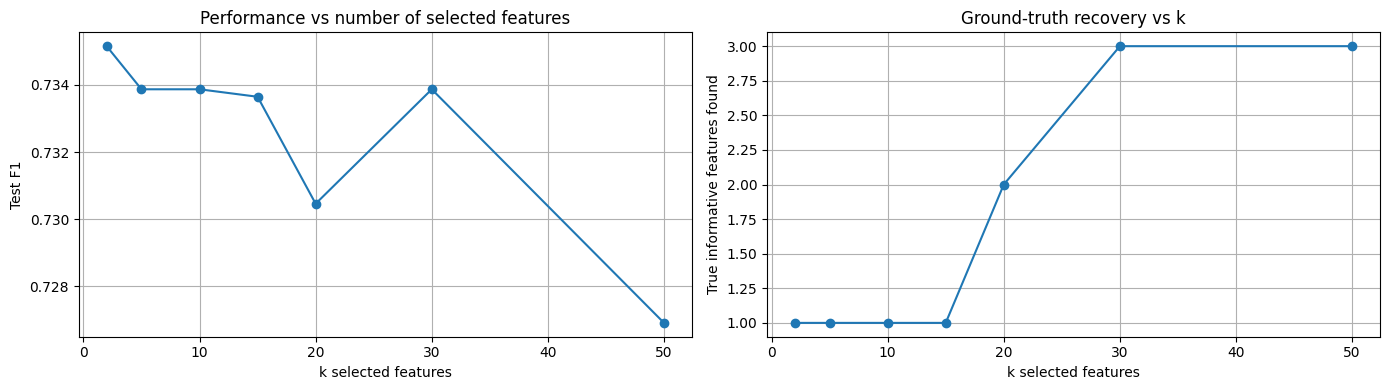

,k,f1,accuracy,n_true_found
0,2,0.735157,0.735333,1
1,5,0.733871,0.736000,1
2,10,0.733871,0.736000,1
3,15,0.733648,0.736667,1
4,20,0.730458,0.733333,2
5,30,0.733871,0.736000,3
6,50,0.726905,0.730000,3


In [25]:

k_values = [2, 5, 10, 15, 20, 30, 50]
curve_rows = []

for k in k_values:
    selector = SelectKBest(score_func=mutual_info_classif, k=k)
    selector.fit(X_train, y_train)
    selected = X_train.columns[selector.get_support()].tolist()
    perf = evaluate_subset_with_logreg(selected, X_train, X_test, y_train, y_test)
    curve_rows.append({
        'k': k,
        'f1': perf['f1'],
        'accuracy': perf['accuracy'],
        'n_true_found': len(set(selected) & set(GROUND_TRUTH))
    })

curve_df = pd.DataFrame(curve_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(curve_df['k'], curve_df['f1'], marker='o')
axes[0].set_title('Performance vs number of selected features')
axes[0].set_xlabel('k selected features')
axes[0].set_ylabel('Test F1')

axes[1].plot(curve_df['k'], curve_df['n_true_found'], marker='o')
axes[1].set_title('Ground-truth recovery vs k')
axes[1].set_xlabel('k selected features')
axes[1].set_ylabel('True informative features found')

plt.tight_layout()
plt.show()

curve_df



## Discussion prompts

1. Why can a method obtain good predictive performance without recovering the exact 5 true informative features?
    - A method can perform well without recovering the exact 5 informative features because redundant or highly correlated variables can carry nearly the same predictive signal.

2. Why are wrapper methods usually slower?
    - Wrapper methods are slower because they repeatedly train a model on many candidate subsets instead of scoring features only once.

3. Why might L1 logistic regression miss some useful variables here?
    - L1 logistic regression may miss useful variables here because correlated features compete with each other, and the L1 penalty tends to keep only a sparse subset.
    
4. If the features were strongly non-linear, which family would you trust more?
    - If the features were strongly non-linear, I would trust tree-based embedded or wrapper methods more than linear methods.

5. If the dataset had 50,000 features, which family would you try first?
    - With 50,000 features, I would start with a fast filter method such as ANOVA or Mutual Information.


# Exercise

Keep the dataset and helpers above. Then complete the tasks below.


## Part A - Warm-up

1. Change `k` from 10 to **5**, **15**, and **20**.
2. For each value, compare **Mutual Information** and **ANOVA**.
3. Which one gives better test F1? Which one finds more true informative features?


In [26]:
from IPython.display import display

def evaluate_selector(selector, X_train, X_test, y_train, y_test, ground_truth, method_name):
    start = time.time()
    selector.fit(X_train, y_train)
    elapsed = time.time() - start
    selected = X_train.columns[selector.get_support()].tolist()
    perf = evaluate_subset_with_logreg(selected, X_train, X_test, y_train, y_test)
    return {
        'method': method_name,
        'execution_time_s': elapsed,
        'n_selected': len(selected),
        'n_true_found': len(set(selected) & set(ground_truth)),
        'accuracy': perf['accuracy'],
        'f1': perf['f1'],
        'selected_features': selected,
    }

part_a_rows = []
for k in [5, 15, 20]:
    part_a_rows.append(
        evaluate_selector(
            SelectKBest(score_func=f_classif, k=k),
            X_train, X_test, y_train, y_test, GROUND_TRUTH,
            f'ANOVA (k={k})'
        )
    )
    part_a_rows.append(
        evaluate_selector(
            SelectKBest(score_func=mutual_info_classif, k=k),
            X_train, X_test, y_train, y_test, GROUND_TRUTH,
            f'Mutual Information (k={k})'
        )
    )

part_a_df = pd.DataFrame(part_a_rows)
part_a_df['execution_time_s'] = part_a_df['execution_time_s'].round(3)
part_a_df['accuracy'] = part_a_df['accuracy'].round(4)
part_a_df['f1'] = part_a_df['f1'].round(4)
display(part_a_df[['method', 'execution_time_s', 'n_true_found', 'accuracy', 'f1']])

,method,execution_time_s,n_true_found,accuracy,f1
0,ANOVA (k=5),0.001,1,0.7360,0.7339
1,Mutual Information (k=5),0.576,1,0.7360,0.7339
2,ANOVA (k=15),0.001,1,0.7360,0.7339
3,Mutual Information (k=15),0.599,1,0.7367,0.7336
4,ANOVA (k=20),0.002,1,0.7293,0.7275
5,Mutual Information (k=20),0.656,2,0.7333,0.7305


### Part A - Conclusions

- For `k=5`, **ANOVA** and **Mutual Information** are effectively tied in F1, and both recover **1** true informative feature.
- For `k=15`, **ANOVA** gives a slightly better F1, while both methods still recover only **1** true informative feature.
- For `k=20`, **Mutual Information** performs better and recovers **2** true informative features, compared with **1** for ANOVA.


## Part B - Main task

Choose **one additional method** and add it to the benchmark.
Possible ideas:
- `SelectKBest(chi2)` on a transformed non-negative version of the data,
- RFE with logistic regression instead of a decision tree,
- a different random forest size,
- a different L1 strength `C`.


In [27]:
# I choose RFE + logistic regression

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)

start = time.time()
rfe_logreg = RFE(
    estimator=LogisticRegression(max_iter=2000, random_state=42),
    n_features_to_select=10,
    step=5,
)
rfe_logreg.fit(X_train_scaled, y_train)
rfe_logreg_elapsed = time.time() - start
rfe_logreg_selected = X_train.columns[rfe_logreg.get_support()].tolist()
rfe_logreg_perf = evaluate_subset_with_logreg(
    rfe_logreg_selected, X_train, X_test, y_train, y_test
)

part_b_row = {
    'method': 'Wrapper (RFE + Logistic Regression)',
    'execution_time_s': round(rfe_logreg_elapsed, 3),
    'n_selected': len(rfe_logreg_selected),
    'n_true_found': len(set(rfe_logreg_selected) & set(GROUND_TRUTH)),
    'accuracy': round(rfe_logreg_perf['accuracy'], 4),
    'f1': round(rfe_logreg_perf['f1'], 4),
}

display(pd.DataFrame([part_b_row]))
print('Selected features:', rfe_logreg_selected)


,method,execution_time_s,n_selected,n_true_found,accuracy,f1
0,Wrapper (RFE + Logistic Regression),0.063,10,1,0.734,0.732


Selected features: ['Feature_11', 'Feature_4', 'Feature_20', 'Feature_10', 'Feature_24', 'Feature_85', 'Feature_5', 'Feature_14', 'Feature_12', 'Feature_7']


## Part C - Interpretation

Write 3 short conclusions:
- Which method would you use if speed matters most?
- Which method would you use if performance matters most?
- Did the best predictive subset match the ground-truth subset exactly?


In [28]:
comparison_rows = []
for method_name, selector in {
    'Filter (ANOVA)': SelectKBest(score_func=f_classif, k=10),
    'Filter (Mutual Information)': SelectKBest(score_func=mutual_info_classif, k=10),
    'Wrapper (RFE + Decision Tree)': RFE(
        estimator=DecisionTreeClassifier(random_state=42),
        n_features_to_select=10,
        step=5,
    ),
}.items():
    comparison_rows.append(
        evaluate_selector(selector, X_train, X_test, y_train, y_test, GROUND_TRUTH, method_name)
    )

start = time.time()
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_selector = SelectFromModel(rf, prefit=True, max_features=10, threshold=-np.inf)
rf_selected = X_train.columns[rf_selector.get_support()].tolist()
rf_elapsed = time.time() - start
rf_perf = evaluate_subset_with_logreg(rf_selected, X_train, X_test, y_train, y_test)
comparison_rows.append({
    'method': 'Embedded (Random Forest)',
    'execution_time_s': rf_elapsed,
    'n_selected': len(rf_selected),
    'n_true_found': len(set(rf_selected) & set(GROUND_TRUTH)),
    'accuracy': rf_perf['accuracy'],
    'f1': rf_perf['f1'],
})

start = time.time()
l1_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        penalty='l1', solver='liblinear', C=0.1,
        random_state=42, max_iter=2000
    ))
])
l1_pipe.fit(X_train, y_train)
coefs = np.abs(l1_pipe.named_steps['clf'].coef_[0])
top_idx = np.argsort(coefs)[::-1][:10]
l1_selected = X_train.columns[top_idx].tolist()
l1_elapsed = time.time() - start
l1_perf = evaluate_subset_with_logreg(l1_selected, X_train, X_test, y_train, y_test)
comparison_rows.append({
    'method': 'Embedded (L1 Logistic)',
    'execution_time_s': l1_elapsed,
    'n_selected': len(l1_selected),
    'n_true_found': len(set(l1_selected) & set(GROUND_TRUTH)),
    'accuracy': l1_perf['accuracy'],
    'f1': l1_perf['f1'],
})

comparison_rows.append({
    'method': part_b_row['method'],
    'execution_time_s': rfe_logreg_elapsed,
    'n_selected': 10,
    'n_true_found': part_b_row['n_true_found'],
    'accuracy': rfe_logreg_perf['accuracy'],
    'f1': rfe_logreg_perf['f1'],
})

comparison_df = pd.DataFrame(comparison_rows).sort_values('f1', ascending=False)
comparison_df['execution_time_s'] = comparison_df['execution_time_s'].round(3)
comparison_df['accuracy'] = comparison_df['accuracy'].round(4)
comparison_df['f1'] = comparison_df['f1'].round(4)
display(comparison_df[['method', 'execution_time_s', 'n_true_found', 'accuracy', 'f1']])


,method,execution_time_s,n_true_found,accuracy,f1
0,Filter (ANOVA),0.002,1,0.7360,0.7339
1,Filter (Mutual Information),0.588,1,0.7360,0.7339
3,Embedded (Random Forest),0.422,1,0.7360,0.7339
2,Wrapper (RFE + Decision Tree),3.976,1,0.7353,0.7334
5,Wrapper (RFE + Logistic Regression),0.063,1,0.7340,0.7320
4,Embedded (L1 Logistic),0.034,1,0.7240,0.7240


### Part C - Conclusions

1. If speed matters most, I would use **ANOVA**, because it is the fastest method.
2. If performance matters most, I would use **ANOVA** here, since it gives the best F1 in this comparison.
3. No, the best predictive subset does **not** match the ground-truth subset exactly; it only recovers **1 of the 5** truly informative features.



## Take-home message

Feature selection is not only about “finding the true variables”. In practice, it is often about balancing:
- **interpretability**,
- **speed**,
- **stability**,
- **predictive performance**.

A feature can be useful because it is truly causal, but also because it is strongly correlated with useful signal.
